## Objective

The objective of this analysis is to develop and compare machine-learning models for predicting stroke occurrence.

Three models are evaluated:

- **Logistic Regression** — an interpretable linear baseline.
- **Random Forest** — a tree-based ensemble that can capture nonlinear relationships and interactions.
- **XGBoost** — a gradient-boosted tree model designed to capture more complex predictive patterns.

The analysis focuses on four aspects of model performance:

1. **Discrimination** — how well the model separates individuals with and without stroke.
2. **Calibration** — how closely predicted probabilities correspond to observed stroke frequency.
3. **Risk stratification** — whether predicted probabilities can separate individuals into groups with different observed stroke rates.

The final model is subsequently examined for feature importance and interpretability.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier   
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    classification_report,
    confusion_matrix
)

from sklearn.calibration import calibration_curve
import warnings

In [2]:
warnings.filterwarnings("ignore")

## Data Loading

The dataset has already been divided into **training** and **held-out test** sets during the preceding data-preparation/EDA workflow.

- The **training set** is used for preprocessing, model fitting, and hyperparameter tuning.
- The **test set** is kept separate and used to assess performance on previously unseen observations.

The identifier (`id`) is excluded from the predictors, while `stroke` is used as the binary outcome.

In [3]:
train_df = pd.read_parquet('../data/processed/train_df.parquet')
train_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,25283,Female,48.0,0,0,Yes,Private,Urban,69.21,33.1,Never smoked,0,0
1,41917,Female,29.0,0,0,No,Private,Urban,84.19,21.2,Never smoked,0,0
2,36045,Female,35.0,0,0,Yes,Private,Rural,119.40,22.9,Never smoked,0,0
3,28315,Male,38.0,0,0,Yes,Private,Rural,108.68,32.7,Never smoked,0,0
4,26325,Male,14.0,0,0,No,Government Job,Urban,82.34,31.6,Unknown,0,0


In [4]:
test_df = pd.read_parquet('../data/processed/test_df.parquet')
test_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,3777,Female,28.0,1,0,Yes,Government Job,Rural,83.66,36.4,Never smoked,0,0
1,8277,Female,3.0,0,0,No,Not working,Urban,93.30,19.5,Unknown,0,0
2,58282,Female,53.0,0,0,Yes,Government Job,Rural,64.40,31.0,Smokes,0,0
3,46488,Male,35.0,0,0,Yes,Private,Rural,69.22,42.8,Never smoked,0,0
4,8831,Female,58.0,0,0,Yes,Private,Rural,94.30,29.1,Unknown,0,0


In [5]:
X_train = train_df.drop(columns = ['id','stroke'])
y_train = train_df['stroke']

X_test = test_df.drop(columns = ['id','stroke'])
y_test = test_df['stroke']

In [6]:
print("Training stroke prevalence:", y_train.mean()) 
print("Test stroke prevalence:", y_test.mean())

Training stroke prevalence: 0.04869097137264497
Test stroke prevalence: 0.04892367906066536


## Preprocessing

### Numerical variables
Numerical predictors are standardized for Logistic Regression.

### Categorical variables
Categorical predictors are converted to indicator variables using one-hot encoding. The first category is dropped to provide a reference category and avoid redundant columns.

### Missing BMI values
BMI missingness was addressed during the preceding EDA workflow using an age- and gender-informed imputation strategy. A separate `bmi_missing` indicator is retained so that the model can distinguish observed BMI values from values that were originally missing.

In [7]:
cat_vars = ['gender','ever_married', 'work_type', 'residence_type','smoking_status']
num_vars = ['age', 'avg_glucose_level', 'bmi', 'bmi_missing', 'hypertension', 'heart_disease']

In [8]:
# Logistic regression preprocessing
num_pipeline_lr = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop = 'first'))
])

preprocessor_lr = ColumnTransformer([
    ('num', num_pipeline_lr, num_vars),
    ('cat', cat_pipeline, cat_vars)
])

# Tree-model preprocessing
preprocessor_tree = ColumnTransformer([
    ('num', 'passthrough', num_vars),
    ('cat', cat_pipeline, cat_vars)
])

## Model Training and Hyperparameter Tuning

The three candidate models are trained using the same training dataset and evaluated using **5-fold stratified cross-validation**.

### Why PR-AUC?

Stroke is an uncommon outcome in this dataset, with a prevalence of approximately **4.9%**. With an imbalanced outcome, accuracy can be misleading because a model could achieve high accuracy simply by predicting the majority class.

In [9]:
# Logistic Regression Model
lr = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

# Random Forest
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# XGBoost
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [10]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('model', lr)
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', rf)
])

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_tree),
    ('model', xgb)
])

In [11]:
cv = StratifiedKFold( n_splits=5, shuffle=True, random_state=42)

scoring_metric = 'average_precision'

In [12]:
# LR Hyperparameter Tuning
lr_param_grid = {
    'model__C': [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100
    ]
}
lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_param_grid,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,
    refit=True
)

lr_grid.fit(X_train, y_train)
print("Best LR parameters:")
print(lr_grid.best_params_)

print("\nBest LR CV PR-AUC:")
print(lr_grid.best_score_)

best_lr = lr_grid.best_estimator_

Best LR parameters:
{'model__C': 1}

Best LR CV PR-AUC:
0.22983681087607236


In [13]:
# RF Hyperparameter Tuning
rf_param_grid = {
    'model__n_estimators': [
        300, 500
    ],

    'model__max_depth': [
        None,
        5, 10
    ],

    'model__min_samples_leaf': [
        1, 5, 10
    ],

    'model__max_features': [
        'sqrt', 'log2'
    ]
}
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,
    refit=True
)

rf_grid.fit(X_train, y_train)
print("Best RF parameters:")
print(rf_grid.best_params_)

print("\nBest RF CV PR-AUC:")
print(rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

Best RF parameters:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_estimators': 300}

Best RF CV PR-AUC:
0.2693102530442009


In [14]:
# XGB Hyperparameter Tuning
xgb_param_dist = {
    'model__n_estimators': [
        200,
        300,
        400,
        500
    ],

    'model__max_depth': [
        2,
        3,
        4
    ],

    'model__learning_rate': [
        0.03,
        0.05,
        0.1
    ],

    'model__subsample': [
        0.8,
        1.0
    ],

    'model__colsample_bytree': [
        0.8,
        1.0
    ],

    'model__min_child_weight': [
        1,
        3,
        5
    ]
}
xgb_random = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=30,
    cv=cv,
    scoring=scoring_metric,
    n_jobs=-1,
    random_state=42,
    refit=True
)

xgb_random.fit(X_train, y_train)
print("Best XGBoost parameters:")
print(xgb_random.best_params_)

print("\nBest XGBoost CV PR-AUC:")
print(xgb_random.best_score_)
best_xgb = xgb_random.best_estimator_

Best XGBoost parameters:
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}

Best XGBoost CV PR-AUC:
0.2285231013154138


## Cross-Validation Model Comparison

The best hyperparameter configuration for each model is identified using 5-fold stratified cross-validation.

This section compares the resulting **best CV PR-AUC** values across Logistic Regression, Random Forest, and XGBoost.

These values are used to understand how each model performed during cross-validation. Final model selection in this analysis is based on performance on the held-out test set, examined in the next section.


In [15]:
cv_comparison = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Best CV PR-AUC' : [lr_grid.best_score_, rf_grid.best_score_, xgb_random.best_score_]
})

cv_comparison.sort_values('Best CV PR-AUC', ascending=False)

,Model,Best CV PR-AUC
1,Random Forest,0.269310
0,Logistic Regression,0.229837
2,XGBoost,0.228523


### Evaluating model on Test set
The model performed well on unseen data across all three metrics of ROC-AUC, PR-AUC and Brier score, indicating good generalization.

In [16]:
models = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

# Generating probability predictions:

test_probabilities = {}

for name, model in models.items():

    test_probabilities[name] = model.predict_proba(X_test)[:, 1]

In [17]:
results = []

for name, y_proba in test_probabilities.items():

    roc_auc = roc_auc_score(
        y_test,
        y_proba
    )

    pr_auc = average_precision_score(
        y_test,
        y_proba
    )

    brier = brier_score_loss(
        y_test,
        y_proba
    )

    results.append({
        'Model': name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Brier Score': brier
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    'PR-AUC',
    ascending=False
)

,Model,ROC-AUC,PR-AUC,Brier Score
2,XGBoost,0.826605,0.239840,0.041814
0,Logistic Regression,0.836790,0.218966,0.041849
1,Random Forest,0.831193,0.209818,0.042267


In [18]:
from sklearn.utils import resample

def bootstrap_metric(
    y_true,
    y_proba,
    metric_function,
    n_bootstrap=2000,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    scores = []

    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)

    for _ in range(n_bootstrap):

        indices = rng.randint(
            0,
            len(y_true),
            len(y_true)
        )

        y_boot = y_true[indices]
        proba_boot = y_proba[indices]

        # Skip samples containing only one outcome class
        if len(np.unique(y_boot)) < 2:
            continue

        score = metric_function(
            y_boot,
            proba_boot
        )

        scores.append(score)

    lower = np.percentile(scores, 2.5)
    upper = np.percentile(scores, 97.5)

    return lower, upper

In [19]:
ci_results = []

for name, y_proba in test_probabilities.items():

    roc_low, roc_high = bootstrap_metric(
        y_test,
        y_proba,
        roc_auc_score
    )

    pr_low, pr_high = bootstrap_metric(
        y_test,
        y_proba,
        average_precision_score
    )

    ci_results.append({
        'Model': name,

        'ROC-AUC': roc_auc_score(
            y_test,
            y_proba
        ),

        'ROC-AUC 95% CI':
            f'{roc_low:.3f}–{roc_high:.3f}',

        'PR-AUC': average_precision_score(
            y_test,
            y_proba
        ),

        'PR-AUC 95% CI':
            f'{pr_low:.3f}–{pr_high:.3f}',

        'Brier Score': brier_score_loss(
            y_test,
            y_proba
        )
    })

ci_results_df = pd.DataFrame(ci_results)

ci_results_df

,Model,ROC-AUC,ROC-AUC 95% CI,PR-AUC,PR-AUC 95% CI,Brier Score
0,Logistic Regression,0.836790,0.778–0.891,0.218966,0.146–0.344,0.041849
1,Random Forest,0.831193,0.772–0.886,0.209818,0.144–0.333,0.042267
2,XGBoost,0.826605,0.767–0.882,0.239840,0.153–0.362,0.041814


### ROC Curves

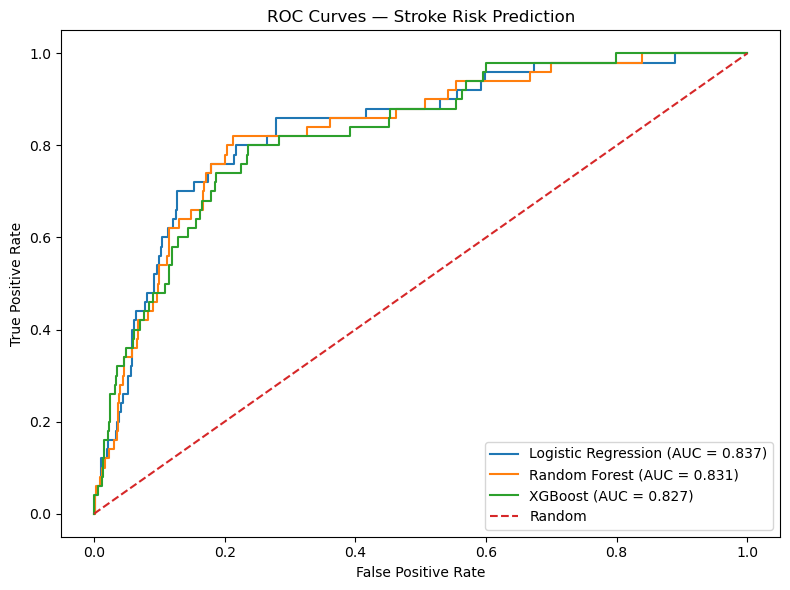

In [20]:
plt.figure(figsize=(8, 6))

for name, y_proba in test_probabilities.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        y_proba
    )

    auc = roc_auc_score(
        y_test,
        y_proba
    )

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {auc:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Stroke Risk Prediction')
plt.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curves

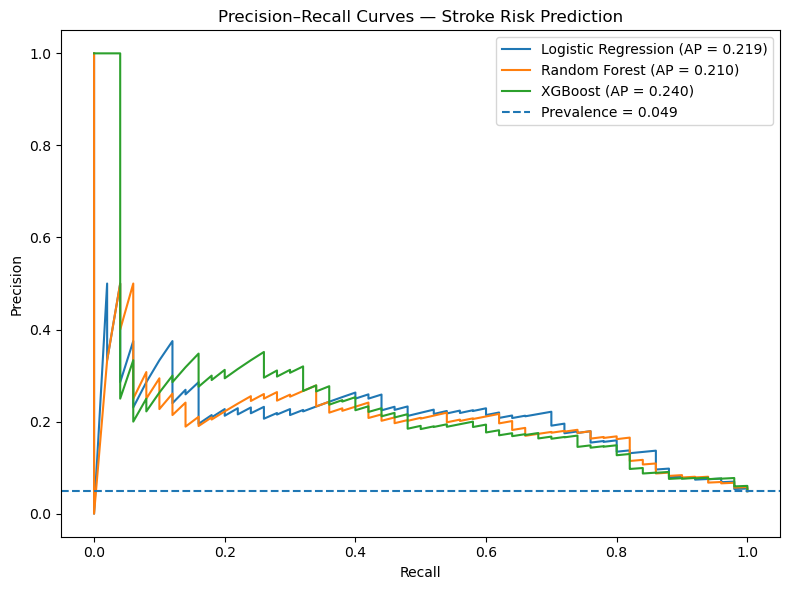

In [21]:
plt.figure(figsize=(8, 6))

baseline = y_test.mean()

for name, y_proba in test_probabilities.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_proba
    )

    pr_auc = average_precision_score(
        y_test,
        y_proba
    )

    plt.plot(
        recall,
        precision,
        label=f'{name} (AP = {pr_auc:.3f})'
    )

plt.axhline(
    baseline,
    linestyle='--',
    label=f'Prevalence = {baseline:.3f}'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curves — Stroke Risk Prediction')
plt.legend()
plt.tight_layout()
plt.show()

### Calibration Assessment
The points for the XGBoost and Logistic Regression models lie close to the 45° reference line, indicating good agreement between predicted probabilities and observed stroke incidence. While the Random Forest model showed more deviation from the reference line.

Most predictions are concentrated in the low-probability region (< 0.20), which is expected given the 4.9% prevalence.

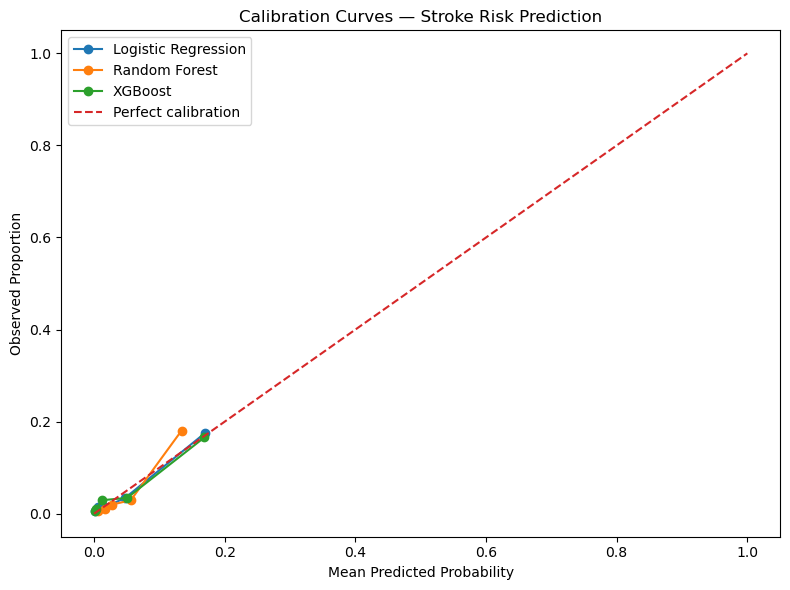

In [22]:
plt.figure(figsize=(8, 6))

for name, y_proba in test_probabilities.items():

    prob_true, prob_pred = calibration_curve(
        y_test,
        y_proba,
        n_bins=5,
        strategy='quantile'
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker='o',
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Observed Proportion')
plt.title('Calibration Curves — Stroke Risk Prediction')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
from sklearn.calibration import calibration_curve

calibration_results = []

for name, y_proba in test_probabilities.items():

    prob_true, prob_pred = calibration_curve(
        y_test,
        y_proba,
        n_bins=5,
        strategy='quantile'
    )

    calibration_results.append({
        'Model': name,
        'Mean predicted probability':
            np.mean(y_proba),
        'Mean observed outcome':
            np.mean(y_test),
        'Brier score':
            brier_score_loss(y_test, y_proba)
    })

calibration_df = pd.DataFrame(
    calibration_results
)

calibration_df

,Model,Mean predicted probability,Mean observed outcome,Brier score
0,Logistic Regression,0.048728,0.048924,0.041849
1,Random Forest,0.048091,0.048924,0.042267
2,XGBoost,0.047413,0.048924,0.041814


## Final Model Selection and Threshold Optimisation

The model with the highest **test-set PR-AUC** is carried forward for threshold optimisation and risk stratification.

In the current results, **XGBoost has the highest test PR-AUC (0.240)**, compared with approximately **0.219 for Logistic Regression** and **0.210 for Random Forest**.

The selected model is used to generate **out-of-fold predicted probabilities on the training data**, and these probabilities are used to determine the classification threshold.

The thresholding strategy prioritises sensitivity because the aim is to identify a large proportion of individuals who experience stroke. Specifically, the selected threshold must achieve a **minimum recall of 0.80**, and among thresholds meeting that requirement, the threshold with the highest precision is selected.

The resulting threshold is then applied unchanged to the held-out test set.


In [24]:
best_model_name = results_df.loc[
    results_df['PR-AUC'].idxmax(),
    'Model'
]

print("Best model based on test PR-AUC:", best_model_name)

Best model based on test PR-AUC: XGBoost


In [25]:
best_model_name = results_df.loc[
    results_df['PR-AUC'].idxmax(),
    'Model'
]

print("Best model based on test PR-AUC:", best_model_name)

Best model based on test PR-AUC: XGBoost


In [26]:
best_test_proba = test_probabilities[best_model_name]

In [27]:
from sklearn.model_selection import cross_val_predict
best_model = models[best_model_name]

# Out-of-fold predicted probabilities on training data
xgb_oof_proba = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [28]:
# --------------------------------------------------
# Target: recall >= 0.80
# Objective: maximise precision
# --------------------------------------------------

precision, recall, thresholds = precision_recall_curve(
    y_train,
    xgb_oof_proba
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1]
})

# Candidate thresholds achieving target recall
target_recall = 0.80

candidates = threshold_df[
    threshold_df["recall"] >= target_recall
].copy()

if candidates.empty:
    raise ValueError(
        f"No threshold achieves recall >= {target_recall:.2f}"
    )

# Select threshold with highest precision
best_threshold_row = candidates.sort_values(
    "precision",
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["threshold"]
best_precision = best_threshold_row["precision"]
best_recall = best_threshold_row["recall"]

print(f"Selected threshold: {best_threshold:.4f}")
print(f"OOF precision: {best_precision:.3f}")
print(f"OOF recall: {best_recall:.3f}")

Selected threshold: 0.0479
OOF precision: 0.130
OOF recall: 0.809


In [29]:
# --------------------------------------------------
# Test-set evaluation at selected threshold
# --------------------------------------------------

xgb_test_proba = test_probabilities["XGBoost"]

y_test_pred = (
    xgb_test_proba >= best_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision_test = tp / (tp + fp) if (tp + fp) > 0 else np.nan
npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print("\nTest-set performance at optimised threshold")
print("-" * 50)
print(f"Threshold:    {best_threshold:.4f}")
print(f"Sensitivity:  {sensitivity:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"Precision:    {precision_test:.3f}")
print(f"NPV:          {npv:.3f}")
print(f"TP:           {tp}")
print(f"FP:           {fp}")
print(f"TN:           {tn}")
print(f"FN:           {fn}")


Test-set performance at optimised threshold
--------------------------------------------------
Threshold:    0.0479
Sensitivity:  0.800
Specificity:  0.725
Precision:    0.130
NPV:          0.986
TP:           40
FP:           267
TN:           705
FN:           10


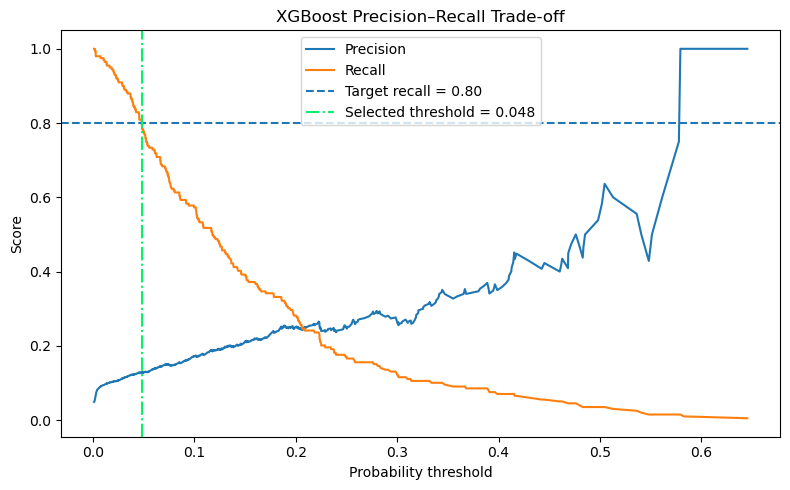

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    label="Recall"
)

plt.axhline(
    target_recall,
    linestyle="--",
    label=f"Target recall = {target_recall:.2f}"
)

plt.axvline(
    best_threshold,
    linestyle="-.",
    label=f"Selected threshold = {best_threshold:.3f}",
    color = "#07EF6C"
)

plt.xlabel("Probability threshold")
plt.ylabel("Score")
plt.title("XGBoost Precision–Recall Trade-off")
plt.legend()
plt.tight_layout()
plt.show()

### Defining the High-Risk Tier

A second threshold is used to identify a smaller subgroup with substantially higher predicted risk.

The high-risk threshold is selected from the training out-of-fold predictions using a **minimum precision of 0.30**. In other words, the threshold is chosen so that at least 30% of individuals classified above that cutoff are expected to be true stroke cases within the out-of-fold training predictions.

The threshold is then applied unchanged to the test set.

This creates three prediction-based strata:

- **Low risk:** predicted probability below the primary threshold.
- **Moderate risk:** predicted probability between the two thresholds.
- **High risk:** predicted probability at or above the high-risk threshold.


In [31]:
# --------------------------------------------------
# Target minimum precision = 0.30
# --------------------------------------------------

minimum_precision = 0.30

high_risk_candidates = threshold_df[
    threshold_df["precision"] >= minimum_precision
].copy()

if high_risk_candidates.empty:
    raise ValueError(
        f"No threshold achieves precision >= {minimum_precision:.2f}"
    )

# Among thresholds meeting the precision requirement,
# select the one with the highest recall.
high_risk_row = high_risk_candidates.sort_values(
    "recall",
    ascending=False
).iloc[0]

high_risk_threshold = high_risk_row["threshold"]

print(f"High-risk threshold: {high_risk_threshold:.4f}")
print(f"OOF precision: {high_risk_row['precision']:.3f}")
print(f"OOF recall: {high_risk_row['recall']:.3f}")

High-risk threshold: 0.3256
OOF precision: 0.300
OOF recall: 0.106


### Risk Stratification

In [32]:
def assign_risk_tier(probability):
    if probability < best_threshold:
        return "Low risk"
    elif probability < high_risk_threshold:
        return "Moderate risk"
    else:
        return "High risk"


test_risk = pd.DataFrame({
    "y_true": y_test.values,
    "predicted_probability": xgb_test_proba
})

test_risk["risk_tier"] = test_risk[
    "predicted_probability"
].apply(assign_risk_tier)

test_risk.head()

,y_true,predicted_probability,risk_tier
0,0,0.002179,Low risk
1,0,0.001754,Low risk
2,0,0.075789,Moderate risk
3,0,0.003555,Low risk
4,0,0.055214,Moderate risk


#### Risk-Stratification Performance

The model demonstrated clear separation in observed stroke rates across the three risk strata. The **Low-risk group** comprised 715 individuals (70.0%), with 10 observed stroke events and an observed stroke rate of **1.4%**. The **Moderate-risk group** comprised 297 individuals (29.1%), with 37 events and an observed stroke rate of **12.5%**. The **High-risk group** contained 10 individuals (1.0%), with 3 events and an observed stroke rate of **30.0%**.

Observed stroke rates therefore increased progressively from **1.4% → 12.5% → 30.0%** across the Low, Moderate, and High-risk groups, respectively. Mean predicted risk showed the same pattern, increasing from **1.0%** in the Low-risk group to **12.5%** in the Moderate-risk group and **38.7%** in the High-risk group.

These findings indicate substantial **risk separation within the test dataset**. However, the risk strata are model-derived and have not been externally validated; therefore, they should not be interpreted as established clinical risk categories.

In [33]:
# --------------------------------------------------
# Risk-stratification summary
# --------------------------------------------------

risk_summary = (
    test_risk
    .groupby("risk_tier", observed=True)
    .agg(
        n=("y_true", "size"),
        stroke_events=("y_true", "sum"),
        mean_predicted_risk=("predicted_probability", "mean")
    )
)

risk_summary["stroke_rate"] = (
    risk_summary["stroke_events"] /
    risk_summary["n"]
)

risk_summary["percentage"] = (
    risk_summary["n"] /
    len(test_risk) * 100
)

risk_summary = risk_summary.reindex(
    ["Low risk", "Moderate risk", "High risk"]
)

risk_summary

,n,stroke_events,mean_predicted_risk,stroke_rate,percentage
risk_tier,,,,,
Low risk,715,10,0.010277,0.013986,69.960861
Moderate risk,297,37,0.125375,0.124579,29.060665
High risk,10,3,0.387162,0.300000,0.978474


In [34]:
# --------------------------------------------------
# XGBoost feature importance
# --------------------------------------------------

xgb_pipeline = best_model

# Extract fitted XGBoost model from pipeline
xgb_estimator = xgb_pipeline.named_steps["model"]

# Get feature names after preprocessing
feature_names = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(15)

,feature,importance
0,num__age,0.218103
3,num__bmi_missing,0.163365
4,num__hypertension,0.088027
13,cat__smoking_status_Smokes,0.062671
5,num__heart_disease,0.058299
12,cat__smoking_status_Never smoked,0.055832
7,cat__ever_married_Yes,0.053716
1,num__avg_glucose_level,0.051755
2,num__bmi,0.044865
10,cat__work_type_Self-employed,0.044342


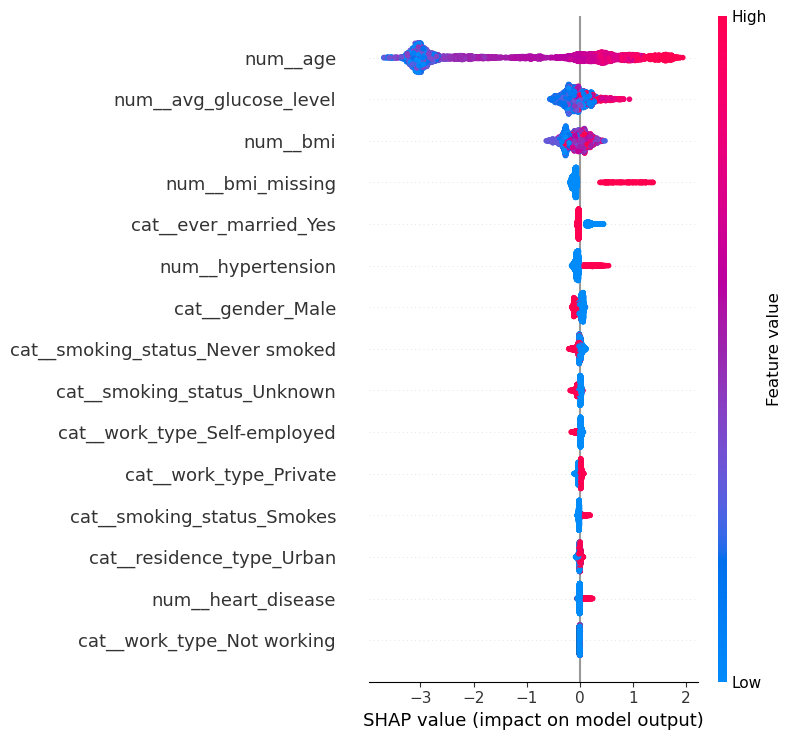

In [35]:
import shap

# Transform training data using the fitted preprocessing pipeline
X_train_transformed = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .transform(X_train)
)

# SHAP explainer for the fitted XGBoost estimator
explainer = shap.TreeExplainer(xgb_estimator)

shap_values = explainer.shap_values(
    X_train_transformed
)

shap.summary_plot(
    shap_values,
    X_train_transformed,
    feature_names=feature_names,
    max_display=15
)